In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("customer_churn_cleaned.csv")

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   Partner                                7043 non-null   int64  
 2   Dependents                             7043 non-null   int64  
 3   tenure                                 7043 non-null   int64  
 4   PhoneService                           7043 non-null   int64  
 5   OnlineSecurity                         5517 non-null   float64
 6   OnlineBackup                           5517 non-null   float64
 7   DeviceProtection                       5517 non-null   float64
 8   TechSupport                            5517 non-null   float64
 9   StreamingTV                            5517 non-null   float64
 10  StreamingMovies                        5517 non-null   float64
 11  PaperlessBillin

In [4]:
df.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,5517.000000,5517.000000,5517.000000,5517.000000,5517.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,0.483033,0.299588,32.371149,0.903166,0.365960,0.440276,0.439007,0.370491,0.490665,0.495197,0.592219,64.761692,2281.916928,0.265370
std,0.368612,0.499748,0.458110,24.559481,0.295752,0.481742,0.496465,0.496311,0.482980,0.499958,0.500022,0.491457,30.090047,2265.270398,0.441561
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,402.225000,0.000000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1397.475000,0.000000
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,3786.600000,1.000000
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,1.000000


In [6]:
df.columns
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [7]:
#“About 27% of customers are leaving the company”

In [9]:
df.columns

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'MultipleLines_No phone service', 'MultipleLines_Yes', 'gender_Male'],
      dtype='str')

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Contract'] = 'Month-to-month'

df.loc[df['Contract_One year'] == 1, 'Contract'] = 'One year'
df.loc[df['Contract_Two year'] == 1, 'Contract'] = 'Two year'

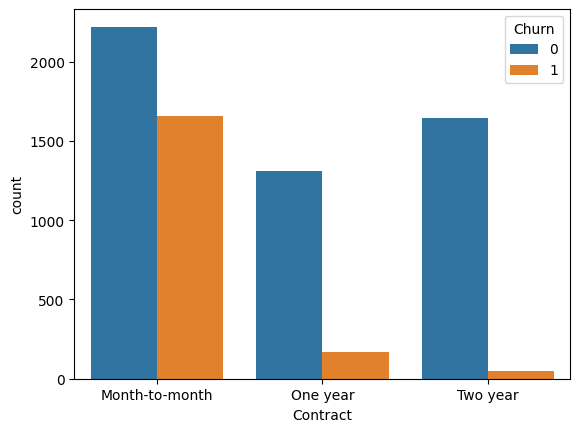

In [11]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

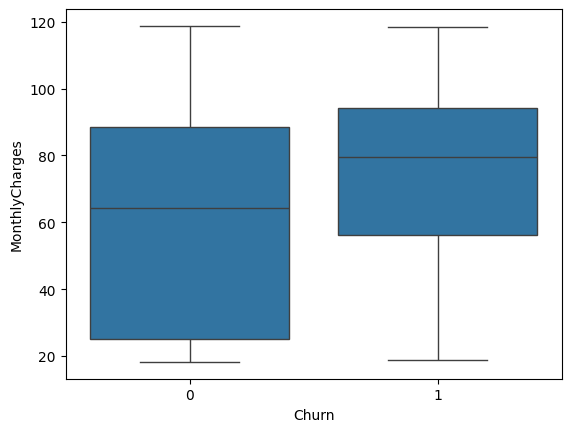

In [14]:
#Customers with month-to-month contracts show significantly higher churn compared to those with one-year or two-year contracts, indicating that lack of long-term commitment increases the likelihood of customer attrition.
#Customers on flexible month-to-month plans are more likely to leave, suggesting that long-term contracts improve customer retention and stability.
sns.boxplot(x='Churn', y='MonthlyCharges',data=df)
plt.show()

In [26]:
#Higher monthly charges may lead to dissatisfaction or perceived lack of value, increasing the likelihood of customers leaving the service.
df = df.select_dtypes(include=['int64', 'float64'])
X = df.drop("Churn", axis=1)
y = df["Churn"]


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

             Feature  Importance
13      TotalCharges    0.251468
12    MonthlyCharges    0.233454
3             tenure    0.196378
5     OnlineSecurity    0.056572
8        TechSupport    0.046382
6       OnlineBackup    0.035576
7   DeviceProtection    0.029040
11  PaperlessBilling    0.027449
1            Partner    0.024916
10   StreamingMovies    0.023429


In [34]:
#1. Charges matter most

#Customers with higher total and monthly charges are more likely to churn.

#2. Tenure is critical

#Customers with shorter tenure are more likely to leave, indicating early-stage dissatisfaction.

#3. Services reduce churn

#Customers without services like Online Security and Tech Support tend to churn more.

from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7814052519517388


In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1036
           1       0.62      0.45      0.52       373

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



In [ ]:
# recall measures the proportion of actual churners that the model correctly identified out of all customers who actually left
#While the model achieved an accuracy of 78%, the recall for churned customers was relatively low (45%), indicating difficulty in identifying all potential churn cases due to class imbalance.

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.63      0.45      0.53       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.69      1409
weighted avg       0.77      0.79      0.77      1409



In [38]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [42]:
#Even after handling class imbalance using class weights, the recall for churn prediction remained relatively low, indicating that churn behavior is complex and may require further feature engineering or advanced techniques.
#“I moved my data from Excel → Database so I can query it using SQL”
import sqlite3

conn = sqlite3.connect("churn.db")
df.to_sql("customers",conn,if_exists="replace",index=False)

7043

In [45]:
query = """
SELECT Churn, COUNT(*)
FROM customers
GROUP BY Churn
"""

pd.read_sql(query, conn)

,Churn,COUNT(*)
0,0,5174
1,1,1869


In [46]:
query = """
SELECT Churn, AVG(MonthlyCharges)
FROM customers
GROUP BY Churn
"""
pd.read_sql(query, conn)

,Churn,AVG(MonthlyCharges)
0,0,61.265124
1,1,74.441332


In [49]:
#high risk customers
query = """
SELECT *
FROM customers
"""
pd.read_sql(query, conn)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
0,0,1,0,1,0,0.0,1.0,0.0,0.0,0.0,0.0,1,29.85,29.85,0
1,0,0,0,34,1,1.0,0.0,1.0,0.0,0.0,0.0,0,56.95,1889.50,0
2,0,0,0,2,1,1.0,1.0,0.0,0.0,0.0,0.0,1,53.85,108.15,1
3,0,0,0,45,0,1.0,0.0,1.0,1.0,0.0,0.0,0,42.30,1840.75,0
4,0,0,0,2,1,0.0,0.0,0.0,0.0,0.0,0.0,1,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,1,1.0,0.0,1.0,1.0,1.0,1.0,1,84.80,1990.50,0
7039,0,1,1,72,1,0.0,1.0,1.0,0.0,1.0,1.0,1,103.20,7362.90,0
7040,0,1,1,11,0,1.0,0.0,0.0,0.0,0.0,0.0,1,29.60,346.45,0
7041,1,1,0,4,1,0.0,0.0,0.0,0.0,0.0,0.0,1,74.40,306.60,1


In [51]:
df.to_csv("churn_final.csv", index=False)